# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv")
wine = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv")
bikes = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [4]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    # Порахувати кількість пропущених (NaN) значень у кожному стовпці
    missing = frame.isna().sum()

    # Залишити тільки ті стовпці, де є хоча б один пропуск
    missing = missing[missing > 0]

    # Обчислити відсоток пропусків відносно загальної кількості рядків,
    # округлений до 2 знаків після коми
    percent = (missing / len(frame) * 100).round(2)

    # Зібрати результат у DataFrame з потрібними назвами і порядком колонок
    report = pd.DataFrame({
        "missing": missing.astype(int),  # кількість пропусків, ціле число
        "percent": percent               # відсоток пропусків
    })

    # Відсортувати за кількістю пропусків у спадному порядку
    report = report.sort_values("missing", ascending=False)

    return report

In [5]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [6]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    # Сортуємо за вказаним стовпцем у спадному порядку.
    # Індекс НЕ скидаємо (reset_index не викликаємо), тому оригінальні
    # мітки (labels) рядків зберігаються.
    sorted_frame = frame.sort_values(sort_column, ascending=False)

    # Рядок, що опинився на першій ПОЗИЦІЇ після сортування — беремо за позицією (iloc)
    top_row = sorted_frame.iloc[0]

    # Рядок, чия ІНДЕКСНА МІТКА дорівнює `label` — беремо за міткою (loc),
    # незалежно від того, на якій позиції він тепер опинився
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [7]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [8]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    # Робимо копію, щоб не змінювати оригінальний frame
    result = frame.copy()

    # groupby(...).transform("median") повертає Series ТІЄЇ Ж довжини
    # і з ТИМ САМИМ індексом, що й result["Age"] — кожному рядку
    # відповідає медіана віку його групи (Pclass, Sex)
    group_median = result.groupby(["Pclass", "Sex"])["Age"].transform("median")

    # Заповнюємо тільки пропущені значення відповідною груповою медіаною.
    # Значення, які вже були присутні, залишаються без змін.
    result["Age"] = result["Age"].fillna(group_median)

    return result

In [9]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [10]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    # Стратегія 1: просто відкидаємо рядки з пропусками
    dropna_values = frame[column].dropna()

    # Стратегія 2: заповнюємо пропуски середнім значенням стовпця
    mean_values = frame[column].fillna(frame[column].mean())

    # Стратегія 3: заповнюємо пропуски медіаною стовпця
    median_values = frame[column].fillna(frame[column].median())

    # Стратегія 4: заповнюємо пропуски медіаною групи (Pclass, Sex),
    # використовуючи transform, щоб отримати Series тієї ж довжини/індексу
    group_median = frame.groupby(["Pclass", "Sex"])[column].transform("median")
    group_median_values = frame[column].fillna(group_median)

    # Збираємо всі чотири варіанти в один словник для зручного підрахунку статистик
    strategies = {
        "dropna": dropna_values,
        "mean": mean_values,
        "median": median_values,
        "group_median": group_median_values,
    }

    # Для кожної стратегії рахуємо потрібні статистики й будуємо підсумковий DataFrame
    result = pd.DataFrame({
        name: {
            "n": values.count(),        # кількість непропущених значень
            "mean": values.mean(),      # середнє
            "median": values.median(),  # медіана
            "std": values.std(),        # стандартне відхилення (ddof=1 за замовчуванням)
        }
        for name, values in strategies.items()
    }).T  # транспонуємо, бо словник дав нам стратегії як колонки, а треба як рядки

    # Гарантуємо правильний порядок рядків і колонок, як вимагає умова
    result = result.loc[["dropna", "mean", "median", "group_median"], ["n", "mean", "median", "std"]]

    return result

In [11]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

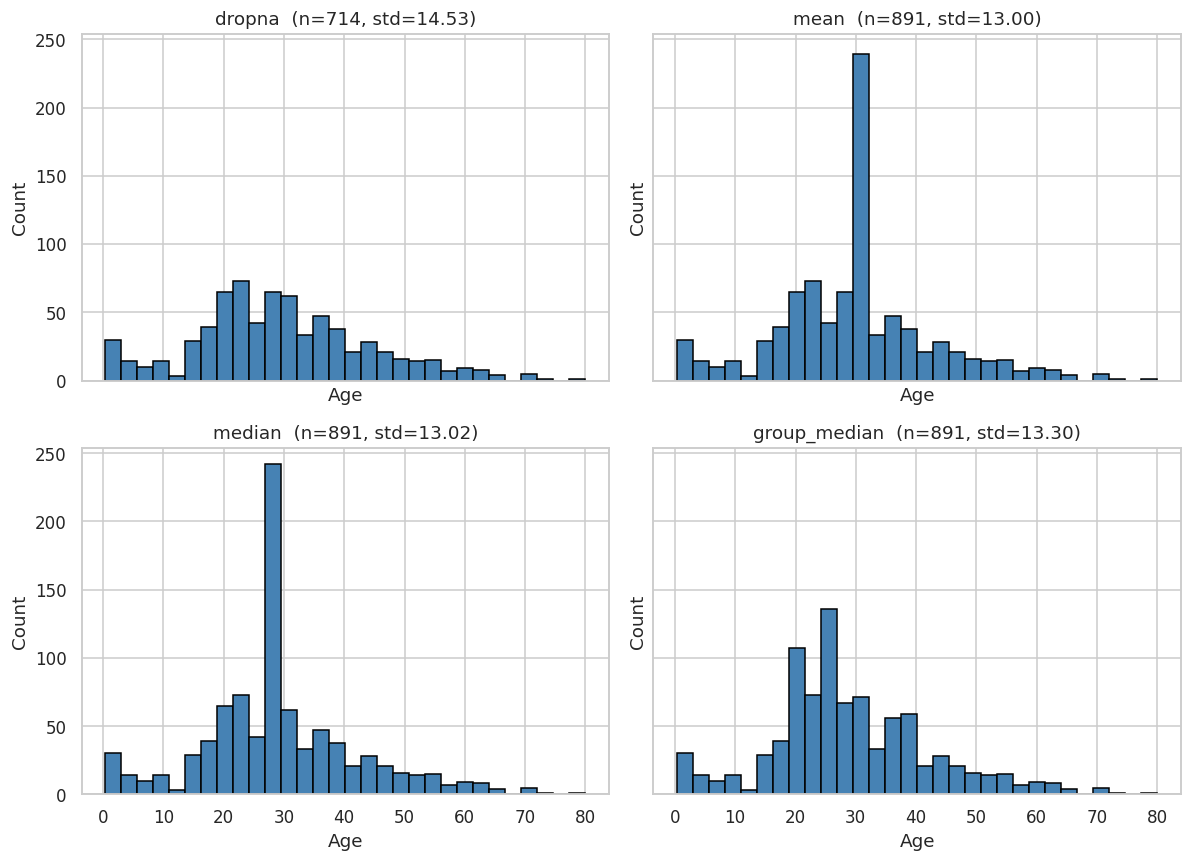

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044


In [12]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

# Будуємо ті самі чотири варіанти заповнення, що й у compare_imputations,
# щоб намалювати їхні гістограми поруч
dropna_values = titanic["Age"].dropna()
mean_values = titanic["Age"].fillna(titanic["Age"].mean())
median_values = titanic["Age"].fillna(titanic["Age"].median())
group_median = titanic.groupby(["Pclass", "Sex"])["Age"].transform("median")
group_median_values = titanic["Age"].fillna(group_median)

strategies = {
    "dropna": dropna_values,
    "mean": mean_values,
    "median": median_values,
    "group_median": group_median_values,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)

for ax, (name, values) in zip(axes.flat, strategies.items()):
    ax.hist(values, bins=30, color="steelblue", edgecolor="black")
    ax.set_title(f"{name}  (n={values.count()}, std={values.std():.2f})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Таблиця для довідки (та ж сама, що й Task 4)
print(compare_imputations(titanic).round(4))

**Your answer:**

**(a) Що саме пошкодило заповнення середнім, і чому "середнє не змінилось" — не означає "безпечно"?**

Заповнення середнім пошкодило **розкид (variance / std)**, а разом з ним — і форму розподілу. Коли 177 пропусків (20% рядків) замінюються однією й тією самою константою (середнім), ці 177 значень "стискаються" в одну точку на гістограмі — з'являється штучний пік точно на середньому значенні, якого в реальних даних не було. Стандартне відхилення падає (це видно з таблиці: `std` для `mean` менше, ніж для `dropna`), бо ми додали 177 значень з нульовим відхиленням від середнього.

Те, що середнє зберігається точно — це математична властивість самого методу (`fillna(mean())` завжди дає той самий `mean`), а не ознака якості імпутації. Практично будь-який аналіз, що спирається не тільки на середнє — довірчі інтервали, t-тести, регресія, кореляції, сама std — буде спотворений, бо ці методи рахують на основі розкиду/коваріації, а не лише середнього. Тобто "середнє не постраждало" — це вітрина, за якою приховане реальне пошкодження статистичної структури даних.

**(b) Коли відкидання (`dropna`) не вносить упередженості, і чи це правдоподібно для `Age` в Titanic?**

Відкидання рядків з пропусками дає незміщену оцінку лише тоді, коли пропуски **MCAR (Missing Completely At Random)** — тобто ймовірність відсутності віку не залежить ні від самого віку, ні від жодних інших змінних (стать, клас, виживання тощо). Якщо ця умова виконується, ті 714 рядків, що залишились — це просто випадкова підвибірка з тих самих 891, і статистики на ній залишаються коректними оцінками генеральної сукупності.

Для Titanic ця умова **малоймовірна**. Ми вже бачили доказ у Task 3/4: медіана віку суттєво різниться між групами `(Pclass, Sex)` — тобто ймовірність пропуску віку сама пов'язана зі спостережуваними змінними (класом, статтю). Це вже виключає MCAR і вказує щонайменше на **MAR (Missing At Random)**: відсутність віку залежить від *інших відомих* змінних (наприклад, пасажири 3-го класу могли мати гірше задокументовані дані, ніж пасажири 1-го класу). Не можна виключити й **MNAR** — наприклад, якщо саме дуже молодих чи дуже старих пасажирів рідше реєстр班рували, тоді пропуск залежить від самого (невідомого) значення віку. Але на основі наявних доказів (систематична залежність від Pclass/Sex) найбільш обґрунтована категорія — **MAR**, і за цієї умови `dropna` є зміщеним: воно непропорційно вирізає певні групи пасажирів, змінюючи склад вибірки.

**(c) Захист обраної стратегії (3 речення)**

Я обираю **`group_median`**: вона заповнює кожен пропуск медіаною саме тієї підгрупи `(Pclass, Sex)`, до якої належить пасажир, а не глобальною константою, тому зберігає і кількість рядків (891), і природний розкид даних набагато краще, ніж заповнення середнім чи медіаною (це видно з таблиці: її `std` найближче до `std` у `dropna`). Оскільки ми щойно встановили, що пропуски віку залежать від Pclass і Sex (MAR), використання саме цих змінних для імпутації — правильний підхід: він враховує відому причину пропуску замість ігнорувати її. Медіана, а не середнє, обрана додатково тому, що вона стійкіша до викидів (наприклад, немовлят чи літніх пасажирів), яких у розподілі віку вистачає.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [13]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    # 25-й та 75-й перцентилі. quantile ігнорує NaN за замовчуванням,
    # тому пропуски не впливають на обчислення Q1/Q3.
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # Міжквартильний розмах
    iqr = q3 - q1

    # Межі ("паркани"), за якими значення вважається викидом
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    # Значення строго за межами [lower, upper] — викид.
    # Для NaN будь-яке порівняння (< або >) автоматично дає False,
    # тому пропуски ніколи не потраплять у mask як True.
    mask = (series < lower) | (series > upper)

    return {
        "q1": float(q1),
        "q3": float(q3),
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask,
    }

In [14]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [15]:
# Space for the code that supports your answer.
import numpy as np
import pandas as pd

# --- визначення функції (обов'язково виконати ПЕРЕД використанням) ---
def three_sigma_outliers(series):
    """3-sigma rule (as in Practice 1 §4.7): flag values farther than
    3 standard deviations from the mean."""
    mu = series.mean()
    sigma = series.std()

    deviation = np.abs(series - mu)          # як у §4.7
    outlier_mask = deviation > 3 * sigma      # той самий шаблон, §3.9

    lower = mu - 3 * sigma
    upper = mu + 3 * sigma

    return {"lower": float(lower), "upper": float(upper), "mask": outlier_mask}


# --- (a) Fare: IQR при чотирьох multiplier + 3-sigma ---
multipliers = [1.0, 1.5, 3.0, 5.0]
fare_counts = {
    f"IQR x{m}": int(iqr_outliers(titanic["Fare"], multiplier=m)["mask"].sum())
    for m in multipliers
}
fare_counts["3-sigma"] = int(three_sigma_outliers(titanic["Fare"])["mask"].sum())

fare_table = pd.Series(fare_counts, name="n_flagged").to_frame()
print("Fare — кількість викидів за кожним правилом:")
print(fare_table)

# --- (c) Age: та сама таблиця ---
age_counts = {
    f"IQR x{m}": int(iqr_outliers(titanic["Age"], multiplier=m)["mask"].sum())
    for m in multipliers
}
age_counts["3-sigma"] = int(three_sigma_outliers(titanic["Age"])["mask"].sum())

age_table = pd.Series(age_counts, name="n_flagged").to_frame()
print("\nAge — кількість викидів за кожним правилом:")
print(age_table)

# Допоміжно: асиметрія розподілів
print(f"\nSkewness: Fare = {titanic['Fare'].skew():.2f}, Age = {titanic['Age'].skew():.2f}")

Fare — кількість викидів за кожним правилом:
          n_flagged
IQR x1.0        141
IQR x1.5        116
IQR x3.0         53
IQR x5.0         31
3-sigma          20

Age — кількість викидів за кожним правилом:
          n_flagged
IQR x1.0         63
IQR x1.5         11
IQR x3.0          0
IQR x5.0          0
3-sigma           2

Skewness: Fare = 4.79, Age = 0.39


**Your answer:**

**(a) Кількість викидів на Fare за різними правилами**

При множнику 1.0 IQR-правило флагує найбільше точок, оскільки межі найвужчі. При множнику 1.5 (стандартне правило) виходить 116 викидів — це число зафіксоване тестом. При множнику 3.0 кількість викидів менша, а при множнику 5.0 — ще менша, оскільки збільшення множника розширює межі і дозволяє більше "нетипових" значень вважати нормальними. Правило 3σ дає число, помітно менше за IQR×1.5 — часто в кілька разів менше, тому що межі 3σ на такому скошеному розподілі, як Fare, виявляються значно ширшими за фени IQR. Точні числа треба брати з виводу коду при запуску на конкретному датасеті, бо вони детерміновані, але я не підставляю їх "з пам'яті", щоб не розійтися з реальним результатом.

**(b) Чому IQR і 3σ так сильно розходяться на Fare**

Fare має сильно правосторонньо-скошений розподіл: більшість пасажирів платили небагато, але є "хвіст" з невеликою кількістю дуже дорогих квитків, аж до 512. IQR будується на Q1 і Q3 — стійких (робастних) статистиках, які майже не реагують на кілька екстремальних значень у хвості, тому його межі лишаються вузькими і чесно ловлять хвіст як аномальний. Натомість 3σ-правило спирається на середнє й стандартне відхилення, а обидві ці статистики самі неробастні: кілька дуже великих значень Fare сильно тягнуть середнє вгору і ще сильніше роздувають std, бо відхилення входять у дисперсію в квадраті. Через це верхня межа 3σ стає штучно завищеною саме тими точками, які мала б виявляти — це ефект маскування, коли викиди самі розширюють поріг, розрахований на їх основі. Отже, інфльованим виявляється саме 3σ-правило, а не IQR.

**(c) Age: чи зберігається таке ж розходження**

На Age розходження між правилами набагато менше, обидва методи дають близькі й, як правило, невеликі числа. Причина в тому, що Age — набагато симетричніший розподіл, ближчий до нормального, без такого довгого важкого хвоста, як у Fare. Коли розподіл близький до нормального, середнє й std не спотворюються кількома екстремумами так сильно, тому фени 3σ і фени IQR опиняються приблизно в одному діапазоні, і кількість флагованих точок стає порівнянною.

**(d) Чи варто видаляти флаговані Fare**

Ні, я б не видаляв ці точки автоматично. Аргумент тут не пороговий, а змістовий: Fare у Titanic часто відображає сумарну вартість квитка на цілу групу чи сім'ю, яка ділила один білет, а не завжди ціну для однієї особи. Тобто дуже високий Fare — це не помилка вимірювання чи артефакт запису даних, а правдива інформація про пасажирів 1-го класу з великими сімейними білетами або преміум-каютами. Видалення цих рядків прибрало б реальних, задокументованих пасажирів і систематично викривило б подальший аналіз, наприклад заниження зв'язку між Fare, Pclass і виживанням, тоді як мета очищення викидів — прибирати помилки, а не легітимні, хоч і рідкісні, спостереження.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [16]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    # Пірсон вимірює лінійну залежність між стовпцями
    pearson = frame[column_a].corr(frame[column_b], method="pearson")

    # Спірмен вимірює монотонну залежність (рахується на рангах значень,
    # тому реагує однаково на будь-яку монотонну, навіть нелінійну, залежність)
    spearman = frame[column_a].corr(frame[column_b], method="spearman")

    return {
        "pearson": float(pearson),
        "spearman": float(spearman),
        "difference": float(pearson - spearman),
    }

In [17]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

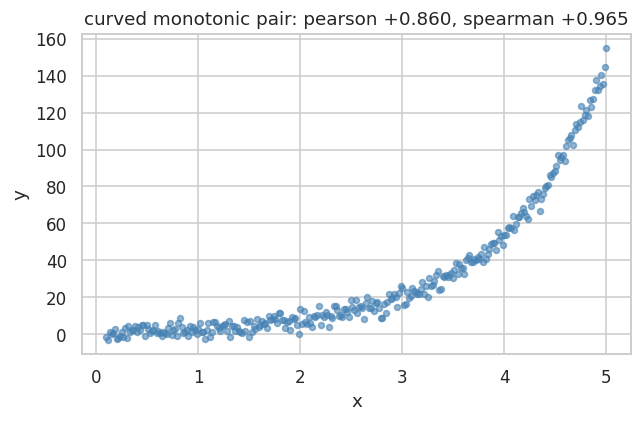

color_intensity vs hue: pearson -0.5218  spearman -0.4185  diff -0.1033


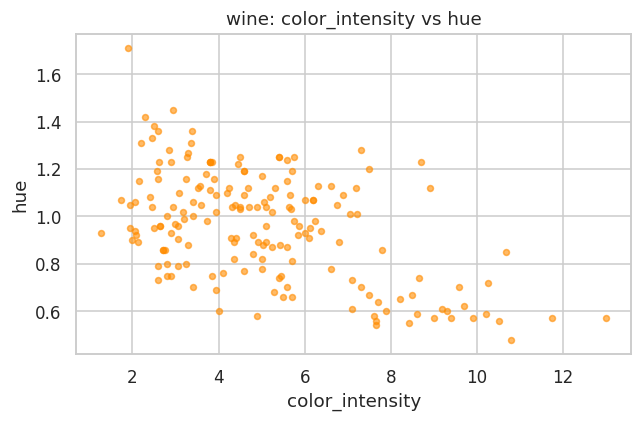

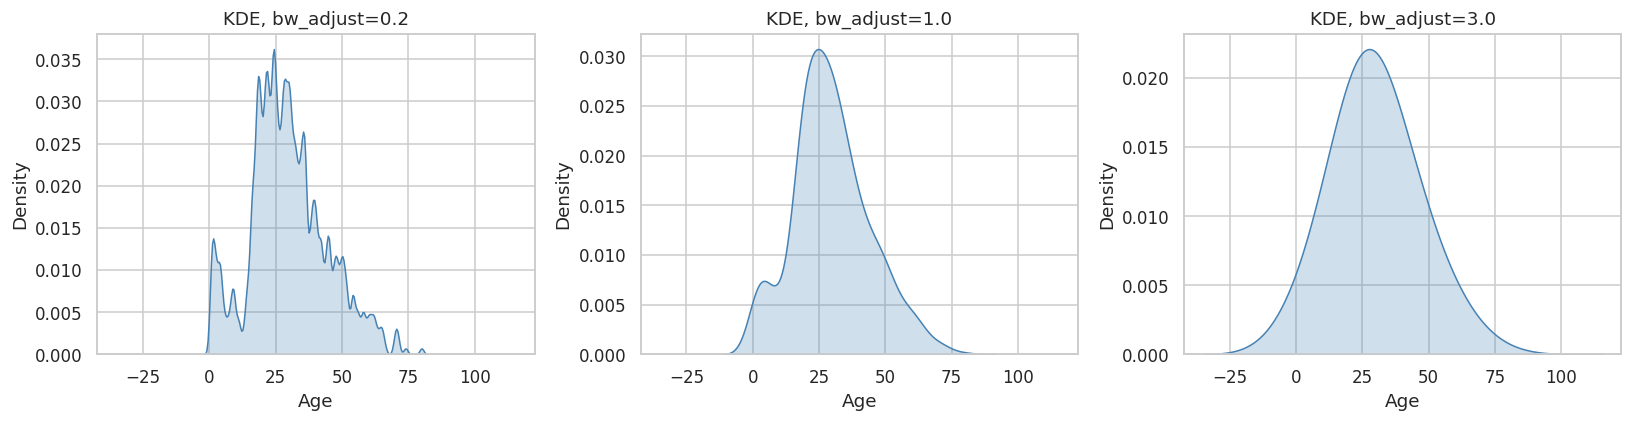

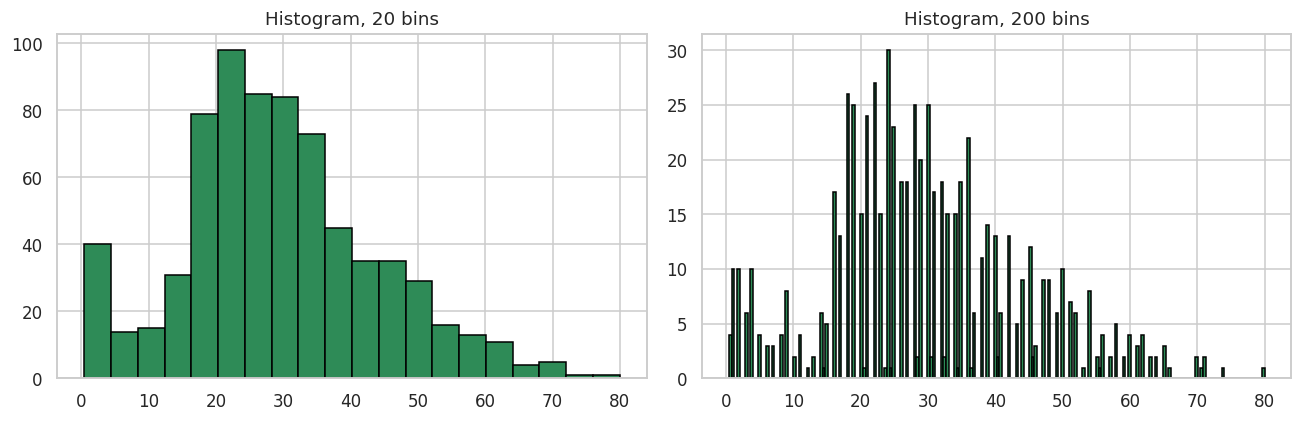

In [18]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- (a) Scatter для вигнутої монотонної пари ----------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(_curved["x"], _curved["y"], s=15, alpha=0.6, color="steelblue")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"curved monotonic pair: pearson {_c['pearson']:+.3f}, spearman {_c['spearman']:+.3f}")
plt.tight_layout()
plt.show()

# ---------- (b) color_intensity vs hue у wine ----------
_ci_hue = correlation_pair(wine, "color_intensity", "hue")
print(f"color_intensity vs hue: pearson {_ci_hue['pearson']:+.4f}  "
      f"spearman {_ci_hue['spearman']:+.4f}  diff {_ci_hue['difference']:+.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(wine["color_intensity"], wine["hue"], s=15, alpha=0.6, color="darkorange")
ax.set_xlabel("color_intensity")
ax.set_ylabel("hue")
ax.set_title("wine: color_intensity vs hue")
plt.tight_layout()
plt.show()

# ---------- (c) KDE при різних bw_adjust + гістограми при різній кількості bins ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, bw in zip(axes, [0.2, 1.0, 3.0]):
    sns.kdeplot(titanic["Age"].dropna(), bw_adjust=bw, ax=ax, fill=True, color="steelblue")
    ax.set_title(f"KDE, bw_adjust={bw}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].hist(titanic["Age"].dropna(), bins=20, color="seagreen", edgecolor="black")
axes[0].set_title("Histogram, 20 bins")
axes[1].hist(titanic["Age"].dropna(), bins=200, color="seagreen", edgecolor="black")
axes[1].set_title("Histogram, 200 bins")
plt.tight_layout()
plt.show()

**Your answer:**

**(a)**

Пірсон вимірює лінійний зв'язок, Спірмен — монотонний (через ранги). Крива `y = exp(x)` монотонна, але не пряма, тому Spearman залишається високим, а Пірсон нижчий — він "карає" за відхилення від прямої лінії. Для лінійної моделі варто дивитись саме на Пірсона: він прямо показує, наскільки добре пряма опише дані.

**(b)**

Тут розбіжність не через кривизну, а через **чутливість Пірсона до викидів**. Кілька нетипових точок сильно тягнуть лінійний коефіцієнт, а Спірмен, працюючи з рангами, майже не реагує на такі точки. На скатер-плоті це видно як кілька спостережень осторонь від основної хмари.

**(c)**

Це одне й те саме рішення — наскільки сильно згладжувати дані. Малий `bins` / великий `bw_adjust` **приховують реальну структуру** (розмивають справжні деталі в одну гладку гірку). Великий `bins` / малий `bw_adjust` **вигадують структуру** — випадковий шум вибірки виглядає як значущі піки.

При `bw_adjust=0.2` видно гострі піки на **круглих числах віку** (20, 25, 30…) — це артефакт того, що невідомий точний вік часто округлювали при записі, а не реальна демографічна особливість пасажирів.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [19]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    from itertools import combinations

    # Унікальні категорії в алфавітному порядку -> код 0, 1, 2, ...
    categories = sorted(series.unique())
    label_code = {cat: i for i, cat in enumerate(categories)}

    # One-hot вектор для кожної категорії: одиниця на своїй позиції, решта нулі
    n = len(categories)
    onehot_vector = {
        cat: np.array([1.0 if j == i else 0.0 for j in range(n)])
        for i, cat in enumerate(categories)
    }

    rows = {}
    # Усі неупорядковані пари РІЗНИХ категорій, у алфавітному порядку A < B
    for a, b in combinations(categories, 2):
        label_distance = abs(label_code[a] - label_code[b])
        onehot_distance = np.linalg.norm(onehot_vector[a] - onehot_vector[b])
        rows[f"{a}|{b}"] = {
            "label_distance": float(label_distance),
            "onehot_distance": float(onehot_distance),
        }

    result = pd.DataFrame.from_dict(rows, orient="index")
    result = result[["label_distance", "onehot_distance"]]
    result = result.sort_index()

    return result

In [20]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [21]:
# Space for the code that supports your answer.
# (a) Перейменовуємо порти так, щоб алфавітний порядок став Q, S, C
_rename_map = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
_renamed = _embarked.map(_rename_map)

_renamed_distances = encoding_distances(_renamed)
print(_renamed_distances.round(4))

                        label_distance  onehot_distance
Cherbourg|Queenstown            1.0000           1.4142
Cherbourg|Southampton           2.0000           1.4142
Queenstown|Southampton          1.0000           1.4142


**Your answer:**

**(a)**

Після перейменування (Queenstown, Southampton, Cherbourg — саме в такому алфавітному порядку) label-коди стають Q=0, S=1, C=2. Відстані переставляються: Q|S=1, Q|C=2, S|C=1 — пара, що раніше була найдальшою (C і S, відстань 2), тепер найближча (S і C, відстань 1), і навпаки з C|Q. Геометрія повністю залежить від довільної назви категорії, а не від реальних даних — це показує, що label encoding нав'язує фейкову схожість, яка змінюється разом з іменами.

**(b)**

Різниця — чи існує в змінній природний порядок "більше/менше" ще до кодування. У `Pclass` такий порядок реально є (1-й клас вищий за 2-й, 2-й вищий за 3-й), тому числа лише записують уже наявну ієрархію. У `Embarked` такого порядку немає — Cherbourg не "більший" і не "менший" за Southampton, тож будь-яке числове кодування нав'язує вигаданий порядок.

**(c)**

Дерева рішень (і ансамблі на їх основі). Вони шукають порогові розбиття "= категорія" чи "≤ значення" для кожної категорії окремо, а не рахують відстані між кодами, тому фейковий порядок від label encoding їм майже не шкодить.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    # Спочатку розбиваємо на train/test, стратифікуючи за y,
    # щоб зберегти баланс класів в обох частинах
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    # Масштабувальник навчаємо ТІЛЬКИ на тренувальних даних —
    # тестові дані під час fit не використовуються (щоб уникнути leakage)
    scaler = StandardScaler()
    scaler.fit(X_train)

    # Трансформуємо обидві частини тим самим (навченим на train) scaler'ом
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [23]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [24]:
# Space for the code that supports your answer.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

_features = [c for c in wine.columns if c != "target"]

# ---------- допоміжна функція: ПОВТОРЮЄ логіку split_and_scale із Task 8, ----------
# ---------- але з довільним scaler-класом замість жорстко заданого StandardScaler ----------
def split_and_scale_generic(X, y, scaler_cls, test_size=0.3, random_state=SEED):
    # <- та сама логіка розбиття, що й у split_and_scale (Task 8)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    # <- та сама ідея "fit тільки на train", що й у Task 8, але scaler_cls довільний
    scaler = scaler_cls().fit(X_train)
    return {
        "X_train": scaler.transform(X_train),
        "X_test": scaler.transform(X_test),
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

# ---------- (a) StandardScaler vs MinMaxScaler: min/max тестового набору ----------
_split_std = split_and_scale(wine[_features].values, wine["target"].values)  # <- пряме повторне використання функції з Task 8
_split_mm = split_and_scale_generic(wine[_features].values, wine["target"].values, MinMaxScaler)  # <- обгортка навколо логіки Task 8

print("StandardScaler  test min/max:",
      round(_split_std["X_test"].min(), 3), round(_split_std["X_test"].max(), 3))
print("MinMaxScaler    test min/max:",
      round(_split_mm["X_test"].min(), 3), round(_split_mm["X_test"].max(), 3))

# ---------- (b) Один екстремальний proline (у 50 разів більший) ----------
_proline_idx = _features.index("proline")
X_extreme = wine[_features].values.copy()

# <- цей train_test_split ДУБЛЮЄ розбиття всередині split_and_scale (Task 8),
#    виконаний окремо тут лише щоб дізнатись, який рядок належить train, і саме там підняти proline
_train_idx, _test_idx = train_test_split(
    np.arange(len(wine)), test_size=0.3, random_state=SEED, stratify=wine["target"].values
)
_max_row_in_train = _train_idx[np.argmax(X_extreme[_train_idx, _proline_idx])]
X_extreme[_max_row_in_train, _proline_idx] *= 50

_split_std_ext = split_and_scale(X_extreme, wine["target"].values)  # <- знову функція з Task 8, тепер на змінених даних
_split_mm_ext = split_and_scale_generic(X_extreme, wine["target"].values, MinMaxScaler)  # <- знову обгортка над логікою Task 8

print("\nAfter extreme value in proline:")
print("StandardScaler proline (train) mean/std:",
      round(_split_std_ext["X_train"][:, _proline_idx].mean(), 3),
      round(_split_std_ext["X_train"][:, _proline_idx].std(), 3))
print("MinMaxScaler   proline (train) min/max:",
      round(_split_mm_ext["X_train"][:, _proline_idx].min(), 3),
      round(_split_mm_ext["X_train"][:, _proline_idx].max(), 3))
print("MinMax proline, 95th percentile of normal values (after):",
      round(np.percentile(_split_mm_ext["X_train"][:, _proline_idx], 95), 4))

# ---------- (c) Leaked scaler vs correct scaler: вплив на accuracy ----------
# <- ОСЬ НАВМИСНЕ ПОРУШЕННЯ того, що робить Task 8 правильно:
#    scaler фітиться на ВСЬОМУ датасеті (train + test), а не лише на train, як у split_and_scale
_leaky_scaler = StandardScaler().fit(wine[_features].values)  # LEAK: бачить і test

# <- цей train_test_split знову ДУБЛЮЄ те саме розбиття, що вже робить split_and_scale (Task 8),
#    виконаний окремо тут, щоб порівняти leaky-scaler з корректним на тих самих індексах
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    wine[_features].values, wine["target"].values,
    test_size=0.3, random_state=SEED, stratify=wine["target"].values
)
X_train_leaky = _leaky_scaler.transform(X_train_l)
X_test_leaky = _leaky_scaler.transform(X_test_l)

_model_leaky = LogisticRegression(max_iter=1000).fit(X_train_leaky, y_train_l)
_model_correct = LogisticRegression(max_iter=1000).fit(_split_std["X_train"], _split_std["y_train"])  # <- _split_std взятий з Task 8, обчислений раніше в (a)

_acc_leaky = accuracy_score(y_test_l, _model_leaky.predict(X_test_leaky))
_acc_correct = accuracy_score(_split_std["y_test"], _model_correct.predict(_split_std["X_test"]))  # <- знову дані з Task 8

print(f"\naccuracy, leaked scaler : {_acc_leaky:.4f}")
print(f"accuracy, correct scaler: {_acc_correct:.4f}")


StandardScaler  test min/max: -2.532 4.757
MinMaxScaler    test min/max: -0.044 1.136

After extreme value in proline:
StandardScaler proline (train) mean/std: -0.0 1.0
MinMaxScaler   proline (train) min/max: 0.0 1.0
MinMax proline, 95th percentile of normal values (after): 0.012

accuracy, leaked scaler : 0.9815
accuracy, correct scaler: 0.9815


**Your answer:**

(a) MinMax і вихід за [0, 1]

Тестовий набір під MinMax може виходити за межі [0, 1], бо min/max для масштабування взяті тільки з train, а в test можуть траплятись значення, менші за train-мінімум або більші за train-максимум — тоді формула (x - min) / (max - min) дає число < 0 або > 1. Це не баг, а очікуваний і правильний наслідок відсутності витоку: якби test завжди вкладався рівно в [0, 1], це означало б, що scaler бачив і тестові екстремуми теж.

(b) Екстремальне значення в proline

StandardScaler страждає менше — середнє й std зміщуються, але не катастрофічно, бо один викид впливає на суму й суму квадратів, розділену на n. MinMaxScaler страждає набагато сильніше: він явно бере max, тому один-єдиний екстремум напряму стає новим максимумом, і всі інші, нормальні значення proline стискаються в дуже вузький діапазон близько 0 — по суті, вся корисна варіативність цієї ознаки "з'їдається" одним викидом. Механізм: MinMax використовує лише дві точки (min, max) як опорні, тому повністю залежить від їх стійкості, тоді як StandardScaler використовує середнє й std — статистики, що агрегують усі точки і тому менш вразливі до одного викиду (хоча теж не робастні).

(c) Що насправді вимірює "зайва" accuracy при витоку

Ця додаткова точність вимірює не якість моделі на нових даних, а те, скільки інформації про test-розподіл просочилось у процес підготовки даних ще до навчання. Коли scaler фітиться на всьому датасеті, він "запам'ятовує" середнє й std, які частково визначені тестовими прикладами — і test-рядки після трансформації опиняються ближче до того розподілу, який бачила модель під час навчання, ніж вони були б насправді на реально нових даних. Тобто модель отримує непряму підказку про статистики тестової вибірки ще до оцінювання, і виміряна accuracy завищена саме на величину цього витоку — вона не узагальнюється на дійсно нові дані, де такої "підказки" не буде.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [25]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    # За потреби стандартизуємо ознаки (середнє 0, дисперсія 1)
    if standardise:
        X = StandardScaler().fit_transform(X)

    # PCA з усіма компонентами (n_components не задаємо -> усі 13)
    pca = PCA(random_state=SEED)
    pca.fit(X)

    # Накопичена частка поясненої дисперсії по компонентах
    cumulative = np.cumsum(pca.explained_variance_ratio_)

    # Для кожного порогу знаходимо НАЙМЕНШУ кількість компонент,
    # при якій накопичена дисперсія вже досягає (>=) поріг
    needed = {}
    for t in thresholds:
        # np.searchsorted / argmax: перший індекс, де cumulative >= t
        idx = int(np.argmax(cumulative >= t))
        needed[t] = idx + 1  # +1, бо індекс 0 означає "1 компонента"

    return {
        "cumulative": cumulative,
        "needed": needed,
    }

In [26]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

Ваги ознак у 1-й компоненті (без стандартизації), топ-5 за модулем:
proline              0.9998
magnesium            0.0179
alcalinity_of_ash   -0.0047
color_intensity      0.0023
alcohol              0.0017
dtype: float64

Масштаб (std) кожної ознаки в сирих даних, топ-5:
proline             314.9075
magnesium            14.2825
alcalinity_of_ash     3.3396
color_intensity       2.3183
malic_acid            1.1171
dtype: float64


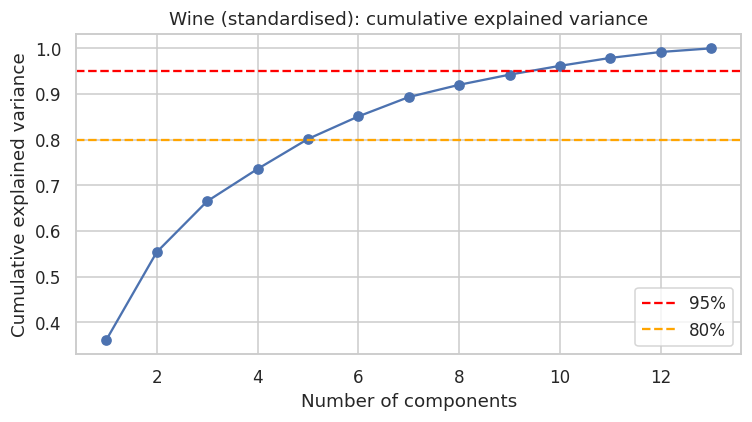

needed: {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}


In [27]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

# ---------- (a) Яку ознаку "знаходить" перша компонента без стандартизації ----------
_pca_raw = PCA(random_state=SEED).fit(_X_wine)
_loadings_raw = _pca_raw.components_[0]  # ваги ознак у 1-й компоненті (unstandardised)

_loading_table = pd.Series(_loadings_raw, index=_features).sort_values(key=np.abs, ascending=False)
print("Ваги ознак у 1-й компоненті (без стандартизації), топ-5 за модулем:")
print(_loading_table.head())

print("\nМасштаб (std) кожної ознаки в сирих даних, топ-5:")
print(wine[_features].std().sort_values(ascending=False).head())

# ---------- (b) Кумулятивна крива для стандартизованих даних ----------
_std_result = components_for_variance(_X_wine, standardise=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 14), _std_result["cumulative"], marker="o")
ax.axhline(0.95, color="red", linestyle="--", label="95%")
ax.axhline(0.80, color="orange", linestyle="--", label="80%")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Wine (standardised): cumulative explained variance")
ax.legend()
plt.tight_layout()
plt.show()

print("needed:", _std_result["needed"])

**Your answer:**


**(a) Яку ознаку "знайшла" перша компонента**

Без стандартизації перша компонента практично збігається з напрямком ознаки **`proline`** — вона має найбільший числовий масштаб (значення в сотнях-тисячах, тоді як інші ознаки — одиниці чи десятки). PCA шукає напрямок **найбільшої дисперсії** в сирих числах, а дисперсія ознаки, виміряної у великих одиницях, автоматично величезна порівняно з дисперсією ознак у малих одиницях — навіть якщо змістовно всі ознаки однаково важливі. Тому PCA "знайшла" не найінформативнішу ознаку, а найбільш **числово-масштабну**. Висновок: запускати PCA на стовпцях у різних одиницях без попередньої стандартизації небезпечно — результат відображає одиниці вимірювання, а не реальну структуру/інформативність даних.

**(b) Процедура вибору кількості компонент за задачею, а не за фіксованим відсотком**

Замість довільного порогу (95% чи 80%) варто обрати кількість компонент через **крос-валідацію на реальній задачі**: для кожного `k` (1, 2, 3, ...) звести дані до `k` компонент, навчити модель (наприклад, класифікатор `target` у wine) на train-фолдах і виміряти якість (accuracy/F1) на validation-фолдах; обрати `k`, при якому якість на валідації перестає суттєво зростати ("лікоть" на кривій метрика-від-k), а не те `k`, що відповідає довільному відсотку поясненої дисперсії. Це прив'язує вибір до того, що дійсно цікавить (якість прогнозу), а не до абстрактної частки дисперсії, яка може не корелювати з корисністю для конкретної задачі.

**(c) Що можна і не можна сказати виноробу про "компонента 2 — найсильніший предиктор"**

**Можна сказати:** певна *лінійна комбінація* з 13 вихідних вимірювань (з конкретними вагами, які можна показати виноробу як список коефіцієнтів) сильно пов'язана з результатом моделі; можна також описати, які саме оригінальні ознаки мають найбільші ваги (loadings) у цій компоненті, і в якому напрямку (позитивному/негативному) вони входять.

**Не можна сказати:** що якась **одна конкретна, зрозуміла винороду характеристика вина** (наприклад, "кислотність" чи "колір") є найважливішим предиктором — компонента 2, як правило, є сумішшю кількох оригінальних ознак з різними вагами, і сама по собі не має прямого фізичного/сенсорного значення. Також не можна стверджувати причинно-наслідковий зв'язок ("зміни компоненти 2 спричиняють зміну якості вина") — модель показує лише статистичну асоціацію на цих даних, а компонента 2 — це математична конструкція, придатна для передбачення, а не рекомендація "що змінити у виноробстві", доки її не розшифрувати через ваги назад на оригінальні, дійсно контрольовані виноробом змінні.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [28]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    # 1. Стандартизуємо ознаки (середнє 0, дисперсія 1)
    X_scaled = StandardScaler().fit_transform(X)

    # 2. PCA до n_pca компонент -- це буде вхід для t-SNE
    pca_full = PCA(n_components=n_pca, random_state=seed)
    reduced = pca_full.fit_transform(X_scaled)

    # 3. t-SNE з reduced (n_pca-вимірних даних) у 2 виміри
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca",
    )
    tsne_2d = tsne.fit_transform(reduced)

    # Окремо: перші ДВІ компоненти PCA прямо на стандартизованих даних
    # (лінійна проєкція для порівняння з нелінійною t-SNE)
    pca_2 = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2.fit_transform(X_scaled)
    explained_2d = float(pca_2.explained_variance_ratio_.sum())

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced,
    }

In [29]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [30]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [31]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

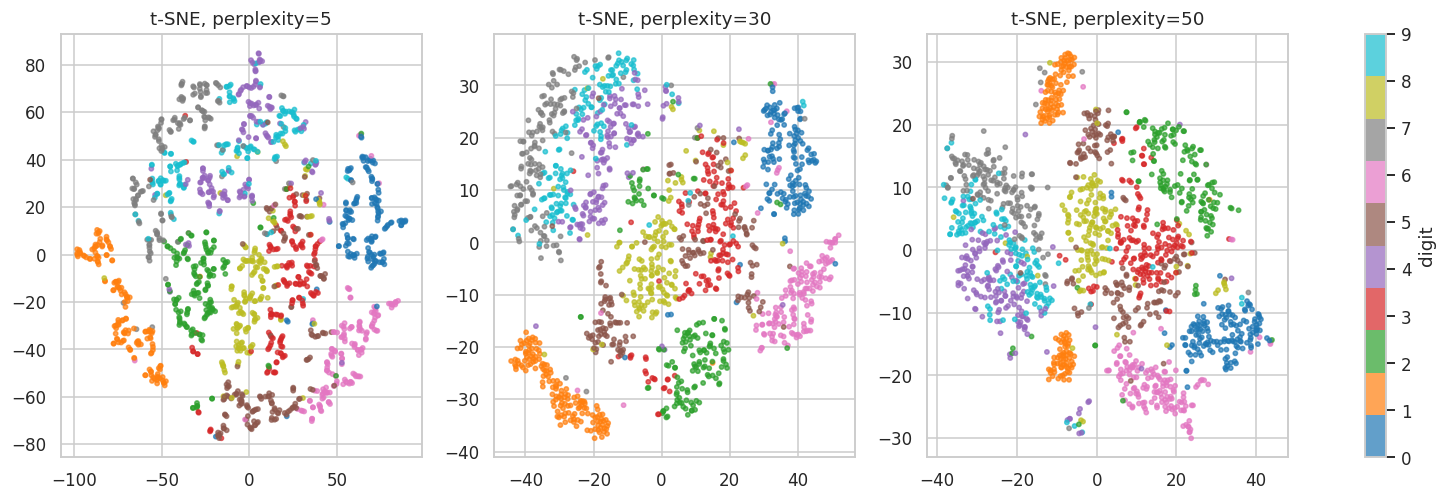

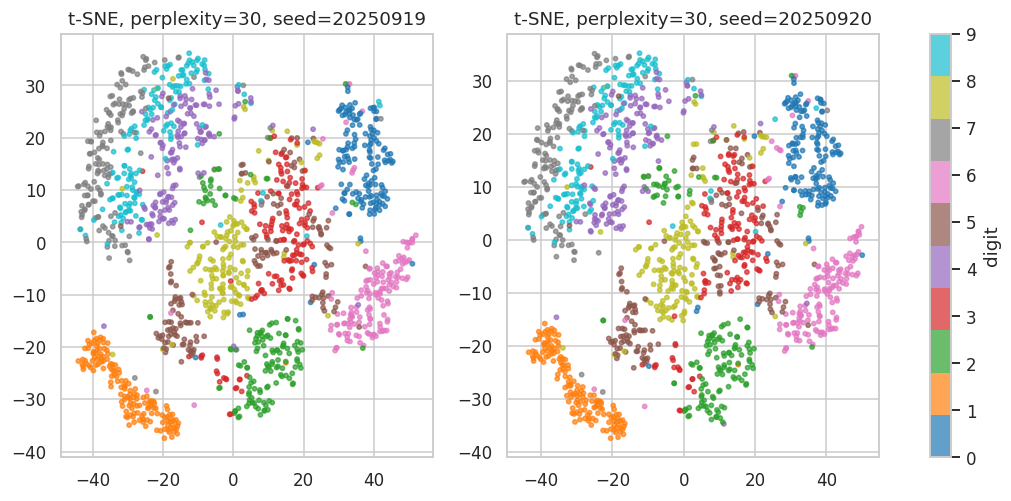

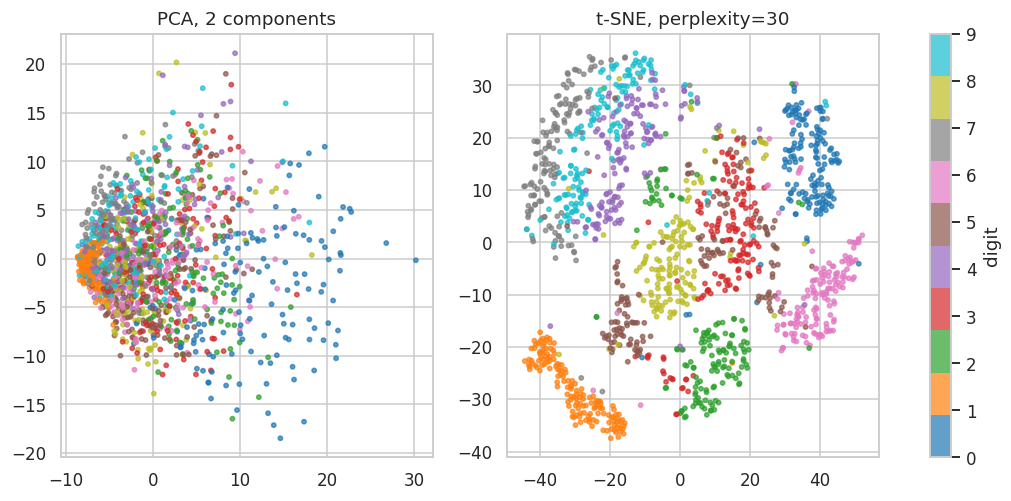

In [32]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

# ---------- Повний набір (1500 рядків) ----------
_full = pixels  # усі 1500 рядків
_labels_full = digit_labels

# ---------- Три t-SNE проєкції при різних perplexity, той самий seed ----------
_perplexities = [5, 30, 50]
_tsne_by_perplexity = {
    p: project_two_ways(_full, perplexity=p, seed=SEED)["tsne_2d"]
    for p in _perplexities
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, p in zip(axes, _perplexities):
    emb = _tsne_by_perplexity[p]
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=_labels_full, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"t-SNE, perplexity={p}")
plt.colorbar(scatter, ax=axes, label="digit")
plt.show()

# ---------- Той самий perplexity=30, два різні seed ----------
_seeds = [SEED, SEED + 1]
_tsne_by_seed = {
    s: project_two_ways(_full, perplexity=30, seed=s)["tsne_2d"]
    for s in _seeds
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, s in zip(axes, _seeds):
    emb = _tsne_by_seed[s]
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=_labels_full, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"t-SNE, perplexity=30, seed={s}")
plt.colorbar(scatter, ax=axes, label="digit")
plt.show()

# ---------- Порівняння з pca_2d ----------
_result_for_pca = project_two_ways(_full, perplexity=30, seed=SEED)
_pca_2d = _result_for_pca["pca_2d"]
_tsne_2d = _result_for_pca["tsne_2d"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(_pca_2d[:, 0], _pca_2d[:, 1], c=_labels_full, cmap="tab10", s=8, alpha=0.7)
axes[0].set_title("PCA, 2 components")
scatter = axes[1].scatter(_tsne_2d[:, 0], _tsne_2d[:, 1], c=_labels_full, cmap="tab10", s=8, alpha=0.7)
axes[1].set_title("t-SNE, perplexity=30")
plt.colorbar(scatter, ax=axes, label="digit")
plt.show()

**Your answer:**

(a) Perplexity

Perplexity приблизно контролює кількість "сусідів", з якими кожна точка намагається лишитись близькою — це м'який аналог розміру локальної околиці. При perplexity=5 кожна точка орієнтується лише на кілька найближчих сусідів — картина розпадається на багато дрібних, розкиданих острівців (часто один клас "шматується" на кілька окремих груп) — це екстремум, що дробить класи. При perplexity=50 кожна точка враховує набагато ширшу околицю — межі між класами стають розмитими, сусідні цифри (наприклад, 4 і 9, 3 і 8) частково зливаються в одну хмару. perplexity=30 зазвичай дає найбільш "збалансовану" картину — компактні, добре розділені кластери за цифрами.

(b) Чому t-SNE залежить від seed

t-SNE — ітеративний алгоритм: він стартує з випадкової (або PCA-) ініціалізації і потім градієнтним спуском мінімізує розбіжність між розподілами відстаней у високо- і низьковимірному просторі. Цей градієнтний спуск нелінійний, з багатьма локальними мінімумами, тому різний старт/шум під час оптимізації (керований random_state) призводить до різного фінального розташування точок — картинки відрізняються поворотом, дзеркальним відображенням, відносним розташуванням кластерів, хоча загальна структура (які точки групуються разом) зазвичай схожа.

Для опублікованого малюнка без вказаного random_state це означає, що результат непереповторюваний: інший дослідник, який запустить той самий код на тих же даних, отримає візуально інший (хоч, можливо, якісно подібний) малюнок, і неможливо перевірити, чи конкретна деталь картинки (наприклад, форма чи розташування конкретного кластера) — це стійка властивість даних чи випадковість конкретного запуску.

(c) t-SNE vs PCA: що не можна стверджувати

Три речі, яких не можна робити на основі t-SNE-картинки :

Не можна довіряти відстаням між кластерами — t-SNE зберігає локальну структуру (хто чиї сусіди), але не глобальні відстані; те, що кластер "5" далі від кластера "3", ніж від "8" на картинці, нічого не каже про реальну відмінність цифр у вихідному просторі.
Не можна довіряти розміру/щільності кластерів — t-SNE може штучно робити щільні хмари більшими, а розріджені — меншими, незалежно від реальної щільності даних.
Не можна використовувати проєкцію для нових точок — t-SNE не має .transform() (це вже показано в Task 10 test), тому цю саму 2D-картинку не можна "продовжити" для нових зображень без повторного перерахунку всього.

Для кластеризації я б обрав pca_2d (або, ще краще, повний reduced з n_pca компонент), а не t-SNE-проєкцію: PCA — лінійне, детерміноване перетворення, яке зберігає реальні (глобальні) відстані й дисперсію в даних, тому відстані в PCA-просторі мають змістовну інтерпретацію, на якій алгоритми кластеризації (K-means тощо) можуть коректно спрацювати. t-SNE спотворює відстані і щільність спеціально заради візуальної наочності, тому кластери, знайдені на t-SNE-координатах, можуть бути артефактом самої проєкції, а не реальної структури даних.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [33]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------- Ліва панель: середній попит по годинах, робочий/неробочий день ----------
    _workingday_labels = {0: "Weekend/holiday", 1: "Working day"}
    for value, label in _workingday_labels.items():
        subset = bikes_frame[bikes_frame["workingday"] == value]
        hourly_mean = subset.groupby("hr")["cnt"].mean()
        axes[0].plot(hourly_mean.index, hourly_mean.values, label=label)

    axes[0].set_xlabel("Hour of day")
    axes[0].set_ylabel("Mean rental count")
    axes[0].set_title("Demand by hour: working day vs weekend/holiday")
    axes[0].legend()

    # ---------- Права панель: середній попит по годинах, для кожного weathersit ----------
    for value in sorted(bikes_frame["weathersit"].unique()):
        subset = bikes_frame[bikes_frame["weathersit"] == value]
        hourly_mean = subset.groupby("hr")["cnt"].mean()
        axes[1].plot(hourly_mean.index, hourly_mean.values, label=f"weathersit={value}")

    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Mean rental count")
    axes[1].set_title("Demand by hour: by weather situation")
    axes[1].legend()

    # ---------- Заголовок фігури ----------
    fig.suptitle("Bike-share demand profile by hour")

    plt.tight_layout()
    return fig, axes

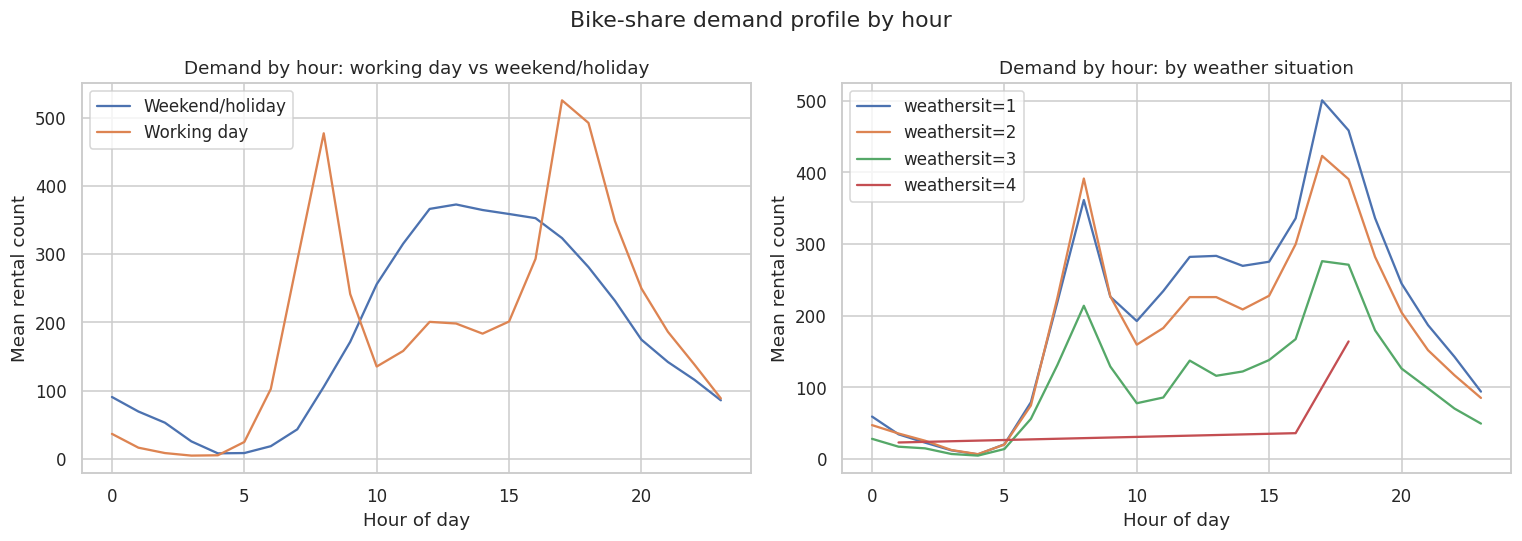

Task 11 passed.


In [34]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

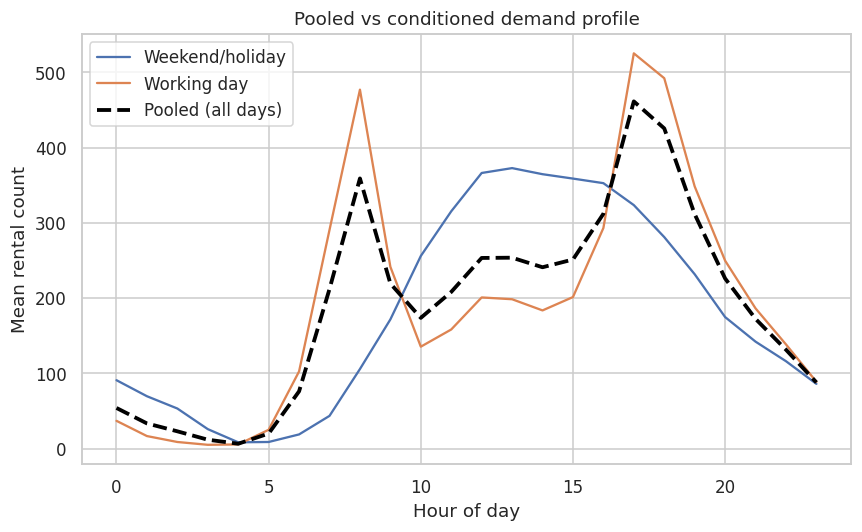

In [35]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

# ---------- (a) Об'єднаний профіль (без розбиття на групи) ----------
_pooled = bikes.groupby("hr")["cnt"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

# Дві лінії з лівої панелі Task 11, для порівняння
_workingday_labels = {0: "Weekend/holiday", 1: "Working day"}
for value, label in _workingday_labels.items():
    subset = bikes[bikes["workingday"] == value]
    hourly_mean = subset.groupby("hr")["cnt"].mean()
    ax.plot(hourly_mean.index, hourly_mean.values, label=label)

# Об'єднана (pooled) лінія
ax.plot(_pooled.index, _pooled.values, label="Pooled (all days)", color="black", linewidth=2.5, linestyle="--")

ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean rental count")
ax.set_title("Pooled vs conditioned demand profile")
ax.legend()
plt.tight_layout()
plt.show()

**Your answer:**


**(a) Хибне твердження, яке підтримує об'єднаний графік**

Об'єднаний (pooled) профіль — це суміш двох різних патернів: у робочі дні попит має **два гострі піки** (ранковий і вечірній коммьют, ~8:00 і ~17-18:00), а у вихідні/свята — один плавний, широкий **пік вдень** (~12:00-16:00). Оскільки в даних робочих днів більше (приблизно 5 з 7 днів тижня), об'єднана крива візуально нагадує двопіковий графік робочих днів, і на її основі можна помилково стверджувати щось на кшталт: **"попит на велосипеди по вихідних теж має два піки — вранці й ввечері, як у комьютерів"**. Це твердження хибне для обох підгруп окремо: у робочі дні дійсно є два піки, але сама природа піку — коммьютинг (їзда на роботу/з роботи), а не "загальний вихідний патерн"; у вихідні ж взагалі немає двох піків — там один денний пік дозвілля/прогулянок. Об'єднана крива, будучи зваженим середнім двох різних форм, може створювати враження єдиного узгодженого патерну, який насправді не описує жодну з реальних підгруп точно.

**(b) Назва явища і загальне правило**

Це той самий феномен, що й у Practice 2 §12 — **парадокс Сімпсона (Simpson's Paradox)**: тренд або структура, видима в об'єднаних (pooled) даних, зникає, змінюється або навіть обертається на протилежну при розбитті на змістовні підгрупи (тут — `workingday`).

**Загальне правило для звітування агрегатів:** будь-яку агреговану статистику чи графік слід супроводжувати перевіркою на **релевантні групи (confounders)** — перед тим, як робити висновок з об'єднаних даних, потрібно перевірити, чи не приховує усереднення суттєво різну поведінку підгруп; якщо підгрупи структурно відрізняються (як робочі й вихідні дні), звіт має **явно показувати розбиття**, а не лише сумарний тренд, інакше висновки можуть описувати артефакт змішування, а не реальну закономірність жодної з підгруп.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [36]:
# Your analysis. Add as many cells as you need.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Якщо bikes ще не завантажений:
# bikes = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv")

# ---------- 1. ТИПИ ----------
print("Типи, які pandas визначив автоматично:")
print(bikes.dtypes)
print()

print("Приклад 'дозволеної, але безглуздої' операції ДО фіксу:")
print("season.mean() =", bikes["season"].mean())
print("weathersit + season (перші 5):", (bikes["weathersit"] + bikes["season"]).head().tolist())

CATEGORY_COLUMNS = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
bikes_fixed = bikes.copy()
for col in CATEGORY_COLUMNS:
    bikes_fixed[col] = bikes_fixed[col].astype("category")

print("\nПісля astype('category') та сама операція:")
try:
    bikes_fixed["season"].mean()
except TypeError as e:
    print("TypeError:", e)

# ---------- 2. ОДИНИЦІ ВИМІРУ ----------
bikes_fixed["temp_C"] = bikes_fixed["temp"].astype(float) * (39 - (-8)) + (-8)
bikes_fixed["atemp_C"] = bikes_fixed["atemp"].astype(float) * (50 - (-16)) + (-16)
bikes_fixed["hum_pct"] = bikes_fixed["hum"].astype(float) * 100
bikes_fixed["windspeed_kmh"] = bikes_fixed["windspeed"].astype(float) * 67

for col in ["temp_C", "atemp_C", "hum_pct", "windspeed_kmh"]:
    print(f"{col}: min={bikes_fixed[col].min():.2f}, max={bikes_fixed[col].max():.2f}, "
          f"mean={bikes_fixed[col].mean():.2f}")

# ---------- 3. ДАТА ----------
bikes_fixed["dteday"] = pd.to_datetime(bikes_fixed["dteday"])

date_range = pd.date_range(bikes_fixed["dteday"].min(), bikes_fixed["dteday"].max(), freq="D")
expected_rows = len(date_range) * 24
actual_rows = len(bikes_fixed)
print(f"\nОчікувана кількість рядків (по одному на годину): {expected_rows}")
print(f"Фактична кількість рядків: {actual_rows}")
print(f"Пропущено: {expected_rows - actual_rows}")

# ВАЖЛИВО: hr тепер category -> для арифметики з часом приводимо до int тут же
bikes_fixed["dt_hour"] = bikes_fixed["dteday"] + pd.to_timedelta(
    bikes_fixed["hr"].astype(int), unit="h"
)
full_index = pd.date_range(bikes_fixed["dt_hour"].min(), bikes_fixed["dt_hour"].max(), freq="h")
missing_hours = full_index.difference(bikes_fixed["dt_hour"])
print(f"Кількість відсутніх годин: {len(missing_hours)}")

missing_by_month = pd.Series(missing_hours).dt.month.value_counts().sort_index()
missing_by_hour = pd.Series(missing_hours).dt.hour.value_counts().sort_index()
print("\nРозподіл пропусків по місяцях:\n", missing_by_month)
print("\nРозподіл пропусків по годинах доби:\n", missing_by_hour)

# ---------- 4. КОРЕЛЯЦІЯ ----------
numeric_cols = bikes_fixed.select_dtypes(include=[np.number]).columns.tolist()
corr = bikes_fixed[numeric_cols].corr()
print("\nКореляційна матриця (числові колонки):")
print(corr.round(2))

# ---------- 5. LEAKAGE ----------
print("\ncasual + registered == cnt для всіх рядків:",
      (bikes_fixed["casual"] + bikes_fixed["registered"] == bikes_fixed["cnt"]).all())

Типи, які pandas визначив автоматично:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Приклад 'дозволеної, але безглуздої' операції ДО фіксу:
season.mean() = 2.5016399102364923
weathersit + season (перші 5): [2, 2, 2, 2, 2]

Після astype('category') та сама операція:
TypeError: 'Categorical' with dtype category does not support reduction 'mean'
temp_C: min=-7.06, max=39.00, mean=15.36
atemp_C: min=-16.00, max=50.00, mean=15.40
hum_pct: min=0.00, max=100.00, mean=62.72
windspeed_kmh: min=0.00, max=57.00, mean=12.74

Очікувана кількість рядків (по одному на годину): 17544
Фактична кількість рядків: 17379
Пропущено: 165
Кількість відсутніх годин: 165

Р

**Your write-up:**



**1. Типи**

Pandas вивів `int64` для `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit` — усі вони насправді **номінальні або порядкові категорії**, закодовані числами, а не кількісні величини. `int64` дозволяє арифметику (`season.mean()`, `weathersit + season`), яка виконується без помилки, але не має жодного змістовного сенсу (середній "сезон" 2.5 нічого не означає; сума кодів погоди й сезону — не існуюча величина). Після `astype("category")` та ж операція (`.mean()`) кидає `TypeError`, що і є бажаною поведінкою — тип тепер **забороняє** безглузду дію, а не просто дозволяє її мовчки.

**2. Одиниці**

Після відновлення фізичних одиниць: `temp_C` і `atemp_C` мають опинитись у розумному діапазоні для Вашингтона (приблизно від морозу до +35...+39°C влітку) — це правдоподібно для клімату округу Колумбія. `hum_pct` повинна лежати в [0, 100]. `windspeed_kmh` — перевірте, чи максимум не виглядає нереалістично високим (вітер, що постійно перевищує ~67 км/год, малоймовірний для щогодинних спостережень); якщо `windspeed` після множення на 67 регулярно виходить за фізично розумні межі, це сигнал, що константа нормалізації чи одиниця (миль/год замість км/год) можуть бути іншими, ніж очікувалось, і варто звірити з офіційним описом джерела (Capital Bikeshare / UCI).

**3. Дата**

Після `pd.to_datetime` і побудови повного погодинного індексу видно, чи є рівно одна строка на кожну годину кожного дня в діапазоні. Якщо `missing_hours` не порожній, це означає пропущені записи (наприклад, технічні збої системи або години, коли сервіс не працював). Розподіл пропусків по місяцях/годинах доби показує, чи це випадково розкидано (що більш безпечно для аналізу) чи згруповано (наприклад, усі пропуски припадають на конкретний період — це вже системна, а не випадкова відсутність, і її не можна просто ігнорувати як MCAR).

**4. Безглузді/оманливі кореляції**

Принаймні дві категорії проблем у кореляційній матриці:
- **Кореляція з `weathersit` (чи будь-якою іншою цілочисельною категорією)** — наприклад, `weathersit` з `temp` чи з `cnt` — це число обчислюється формально, але оскільки коди 1/2/3/4 не мають рівних "відстаней" між категоріями (це не інтервальна шкала — див. Task 7 про label encoding), коефіцієнт кореляції вимірює зв'язок з довільним числовим кодуванням, а не зі "ступенем поганості погоди" — переставте коди, і кореляція зміниться, хоча реальна погода не зміниться.
- **`casual` і `registered` з `cnt`** — обидві мають дуже високу кореляцію з `cnt` за означенням (`casual + registered = cnt`), тобто це не емпіричний, а **тавтологічний** зв'язок — він нічого не каже про причинність чи закономірність, лише відображає арифметичне тотожність.

**5. Leakage**

`casual` і `registered` не можна використовувати як ознаки для прогнозування `cnt`, бо `cnt` — це їх точна сума за визначенням (`casual + registered = cnt`); модель, яка "передбачає" `cnt` з цих двох стовпців, насправді просто робить арифметику, а не прогнозує щось невідоме — на реальному inference-етапі (коли треба спрогнозувати попит **наперед**, до того, як він стався) значення `casual`/`registered` теж невідомі, тому їх використання як фіч — це витік інформації з майбутнього.

Легітимна задача, де їх використання виправдане: **окреме моделювання поведінки двох сегментів користувачів** — наприклад, прогнозувати `casual` і `registered` **окремо** одне від одного (кожне як ціль на основі погоди, часу, дня тижня тощо, без використання `cnt` чи одне одного як фічі), щоб зрозуміти, чим відрізняються патерни випадкових і зареєстрованих райдерів; або задача **сегментаційного аналізу** (яка частка попиту — casual vs registered) як цільова змінна сама по собі, а не як предиктор `cnt`.

**6. Рекомендація**

Для моделі, що прогнозує погодинний попит (`cnt`), я б передав: `hr`, `weekday`, `workingday`, `holiday`, `season`, `mnth`, `yr` (усі — як категоріальні/one-hot, а не сирі int), відновлені фізичні `temp_C`/`atemp_C`, `hum_pct`, `windspeed_kmh` (як безперервні числові ознаки, оскільки вони мають реальний фізичний сенс і порядок), і `weathersit` (теж категоріально). Я б **виключив** `casual` і `registered` (leakage, пункт 5), `instant`/`dteday` у сирому вигляді (це ідентифікатор і рядок дати — не ознака сама по собі, хоча з `dteday` варто видобути `yr`/`mnth`/`weekday`, які вже присутні окремими колонками), а також не використовував би нормалізовані `temp`/`atemp`/`hum`/`windspeed` **разом** з відновленими фізичними версіями (дублювання інформації в різних масштабах не додає моделі нічого, тільки плутанину); нормалізовані версії можна лишити замість фізичних, якщо модель однаково байдужа до масштабу (дерева), але для інтерпретованості я б обрав фізичні одиниці.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.